In [1]:
import os
import pytensor

# Point PyTensor to conda-forge g++ for JIT compilation
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    pytensor.config.cxx = os.path.join(conda_prefix, "Library", "bin", "g++.exe") # type: ignore

from collections.abc import Sequence
from typing import cast

import matplotlib.pyplot as plt
import numpy as np

from analysis.distributions import (
    Bayesian,
    DirichletMixture,
    Distribution,
    GammaFromMeanSD,
)
from analysis.psa.parameters import Parameter
from persistence.context import ModelContext
from persistence.schemas.clinicals import StudyEstimate
from utils.logging import setup_root_logger
from utils.path_utils import get_project_root

%matplotlib inline

logger = setup_root_logger()
root = get_project_root()



# Loaded data
context = ModelContext.load()

# Unpack
seed = context.simulation.environment.seed
mode: str = context.simulation.environment.mode
rng = np.random.default_rng(seed)
sample_size = (
    context.simulation.psa.production
    if mode == "production"
    else context.simulation.psa.development
)
# ----------------------------------------------
# Annual bleeding rate meta-analysis studies
# ----------------------------------------------
meta_components = {
    "on_demand": {
        "bayesian": [
            StudyEstimate(mean=s.mean, sd=s.sd, size=s.size)
            for s in context.clinical.evidence.abr.on_demand
        ],
        "dirichlet": cast(
            Sequence[Distribution],
            [
                GammaFromMeanSD(mean=s.mean, sd=s.sd)
                for s in context.clinical.evidence.abr.on_demand
            ],
        ),
    },
    "prophylaxis": {
        "bayesian": [
            StudyEstimate(mean=s.mean, sd=s.sd, size=s.size)
            for s in context.clinical.evidence.abr.prophylaxis
        ],
        "dirichlet": cast(
            Sequence[Distribution],
            [
                GammaFromMeanSD(mean=s.mean, sd=s.sd)
                for s in context.clinical.evidence.abr.prophylaxis
            ],
        ),
    },
}


on_demand_abr_param = {
    "bayesian": Parameter(
        distribution=Bayesian(studies=meta_components["on_demand"]["bayesian"])
    ),
    "dirichlet": Parameter(
        distribution=DirichletMixture(
            components=meta_components["on_demand"]["dirichlet"]
        )
    ),
}
prophylaxis_abr_param = {
    "bayesian": Parameter(
        distribution=Bayesian(studies=meta_components["prophylaxis"]["bayesian"])
    ),
    "dirichlet": Parameter(
        distribution=DirichletMixture(
            components=meta_components["prophylaxis"]["dirichlet"]
        )
    ),
}

samples = {
    "on_demand": {
        "bayesian": on_demand_abr_param["bayesian"].sample(sample_size, rng),
        "dirichlet": on_demand_abr_param["dirichlet"].sample(sample_size, rng),
    },
    "prophylaxis": {
        "bayesian": prophylaxis_abr_param["bayesian"].sample(sample_size, rng),
        "dirichlet": prophylaxis_abr_param["dirichlet"].sample(sample_size, rng),
    },
}

Initializing NUTS using jitter+adapt_diag...


[20:18:20] INFO     Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


[20:18:21] INFO     Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, tau, z]


...

[20:18:47] INFO     Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, tau, z]


[20:18:47] INFO     NUTS: [mu, tau, z]


Sampling 4 chains for 2_000 tune and 2_500 draw iterations (8_000 + 10_000 draws total) took 14 seconds.


[20:19:01] INFO     Sampling 4 chains for 2_000 tune and 2_500 draw iterations (8_000 + 10_000 draws total) took 14 seconds.


In [2]:
import pickle

path = root / "cache/samples.pkl"
with open(path, "wb") as f:
    pickle.dump(samples, f)

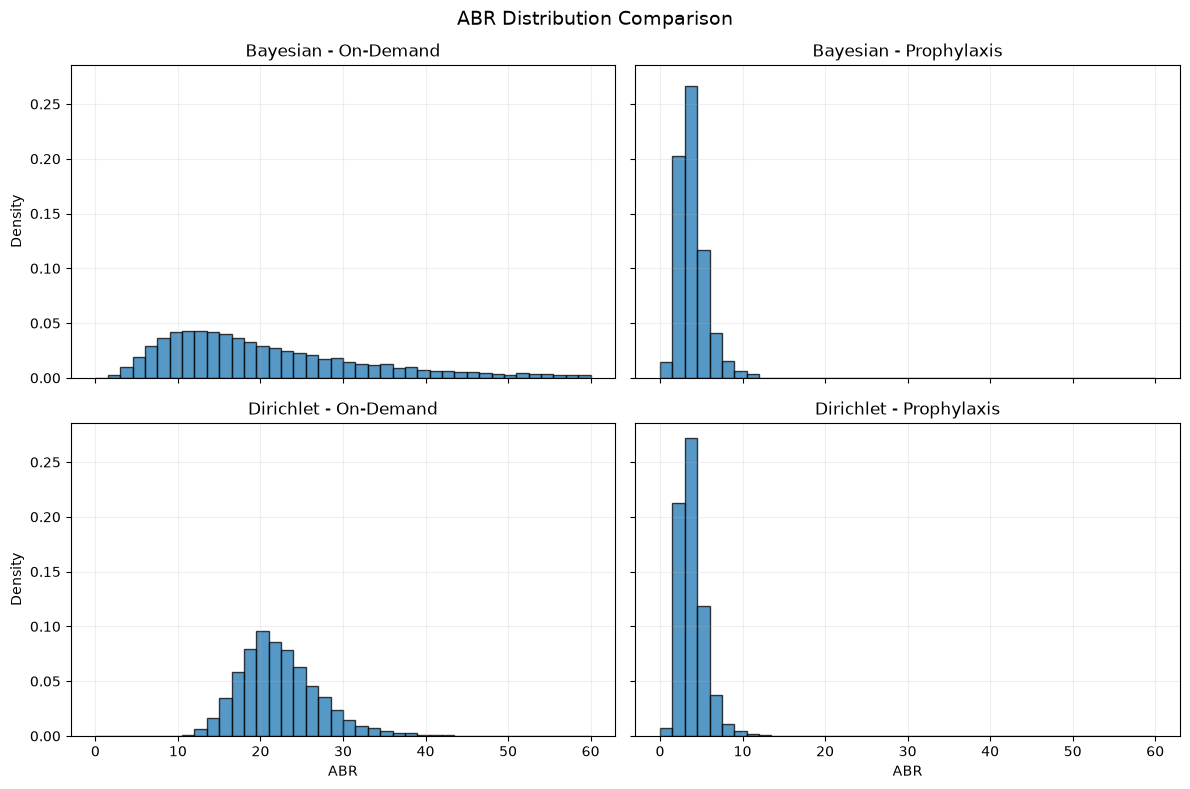

In [3]:
# -----------------------------------
# ** Plot (2x2 layout) **
# -----------------------------------
# Helper
def plot_hist(ax, data, title):
    ax.hist(
        data,
        bins=40,
        range=(0, 60),  # tighter range improves visibility
        density=True,
        alpha=0.75,
        edgecolor="black",
    )
    ax.set_title(title)
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle("ABR Distribution Comparison", fontsize=14)


# --- Bayesian ---
plot_hist(
    axes[0, 0],
    samples["on_demand"]["bayesian"],
    "Bayesian - On-Demand",
)
plot_hist(
    axes[0, 1],
    samples["prophylaxis"]["bayesian"],
    "Bayesian - Prophylaxis",
)

# --- Dirichlet ---
plot_hist(
    axes[1, 0],
    samples["on_demand"]["dirichlet"],
    "Dirichlet - On-Demand",
)
plot_hist(
    axes[1, 1],
    samples["prophylaxis"]["dirichlet"],
    "Dirichlet - Prophylaxis",
)


# Axis labels (clean separation)
axes[1, 0].set_xlabel("ABR")
axes[1, 1].set_xlabel("ABR")
axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [4]:
# -----------------------------------------
# Logging ABR Values
# -----------------------------------------


def summarize(x: np.ndarray) -> dict:
    return {
        "n": len(x),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "median": float(np.median(x)),
        "p25": float(np.percentile(x, 25)),
        "p75": float(np.percentile(x, 75)),
        "p2_5": float(np.percentile(x, 2.5)),
        "p97_5": float(np.percentile(x, 97.5)),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
    }


abr_stats = {
    "Bayesian - On-Demand": summarize(samples["on_demand"]["bayesian"]),
    "Bayesian - Prophylaxis": summarize(samples["prophylaxis"]["bayesian"]),
    "Dirichlet - On-Demand": summarize(samples["on_demand"]["dirichlet"]),
    "Dirichlet - Prophylaxis": summarize(samples["prophylaxis"]["dirichlet"]),
}

for name, s in abr_stats.items():
    logger.info(f"\n=== {name} ===")
    logger.info(f"N: {s['n']}")
    logger.info(f"Mean: {s['mean']:.2f}")
    logger.info(f"SD: {s['std']:.2f}")
    logger.info(f"Median: {s['median']:.2f}")
    logger.info(f"IQR: [{s['p25']:.2f}, {s['p75']:.2f}]")
    logger.info(f"95% CrI: [{s['p2_5']:.2f}, {s['p97_5']:.2f}]")
    logger.info(f"Range: [{s['min']:.2f}, {s['max']:.2f}]")

[20:19:02] INFO     
=== Bayesian - On-Demand ===
[20:19:02] INFO     N: 10000
[20:19:02] INFO     Mean: 22.58
[20:19:02] INFO     SD: 16.24
[20:19:02] INFO     Median: 18.06
[20:19:02] INFO     IQR: [11.64, 28.45]
[20:19:02] INFO     95% CrI: [4.85, 66.98]
[20:19:02] INFO     Range: [1.12, 103.71]
[20:19:02] INFO     
=== Bayesian - Prophylaxis ===
[20:19:02] INFO     N: 10000
[20:19:02] INFO     Mean: 3.87
[20:19:02] INFO     SD: 1.64
[20:19:02] INFO     Median: 3.57
[20:19:02] INFO     IQR: [2.74, 4.66]
[20:19:02] INFO     95% CrI: [1.54, 8.13]
[20:19:02] INFO     Range: [0.57, 10.54]
[20:19:02] INFO     
=== Dirichlet - On-Demand ===
[20:19:02] INFO     N: 10000
[20:19:02] INFO     Mean: 22.26
[20:19:02] INFO     SD: 4.79
[20:19:02] INFO     Median: 21.67
[20:19:02] INFO     IQR: [18.96, 24.98]
[20:19:02] INFO     95% CrI: [14.48, 33.52]
[20:19:02] INFO     Range: [9.09, 51.78]
[20:19:02] INFO     
=== Dirichlet - Prophylaxis ===
[20:19:02] INFO     N: 10000
[20:19:02] INFO     Mea

In [5]:
# -----------------------------------------------------------
# Meta-analysis diagnostics, heterogeneity & comparison table
# -----------------------------------------------------------

import pandas as pd
from IPython.display import display

# --- 1. Convergence diagnostics ---

print("=" * 60)
print("BAYESIAN CONVERGENCE DIAGNOSTICS")
print("=" * 60)

for label, param in [
    ("On-Demand ABR", on_demand_abr_param["bayesian"]),
    ("Prophylaxis ABR", prophylaxis_abr_param["bayesian"]),
]:
    bayes = cast(Bayesian, param.distribution)
    diag = bayes.convergence_diagnostics()
    print(f"\n--- {label} ---")
    rhat_ok = 'Y' if diag['r_hat'] < 1.01 else 'N'
    ess_ok = 'Y' if diag['ess'] > 400 else 'N'
    print(f"  Max R-hat:   {diag['r_hat']:.4f}  [{rhat_ok}]  (< 1.01)")
    print(f"  Min ESS:     {diag['ess']}  [{ess_ok}]  (> 400)")
    print(f"  Divergences: {diag['divergences']}")
    print(f"  Converged:   {diag['converged']}")

# --- 2. Heterogeneity (tau & I^2) ---

print("\n" + "=" * 60)
print("HETEROGENEITY")
print("=" * 60)

print("\nNote: I^2 = proportion of total variability due to between-study heterogeneity.")
print("      25% = low, 50% = moderate, 75% = high (Higgins & Thompson, 2002)")

for label, param in [
    ("On-Demand ABR", on_demand_abr_param["bayesian"]),
    ("Prophylaxis ABR", prophylaxis_abr_param["bayesian"]),
]:
    bayes = cast(Bayesian, param.distribution)
    stats = bayes.get_distribution_stats()
    print(f"\n--- {label} ---")
    print(f"  Pooled effect (exp(mu)): {stats['point_estimate']:.2f} ABR/year")
    print(f"  Between-study SD (tau): {stats['tau_mean']:.2f}  (median: {stats['tau_median']:.2f})")
    print(f"  I^2 (mean):               {stats['I2_mean']:.1%}")
    print(f"  I^2 (median):             {stats['I2_median']:.1%}")

# --- 3. Study-level posterior estimates (shrinkage) ---

print("\n" + "=" * 60)
print("STUDY-LEVEL POSTERIOR MEANS (shrinkage toward pooled effect)")
print("=" * 60)

for label, param in [
    ("On-Demand ABR", on_demand_abr_param["bayesian"]),
    ("Prophylaxis ABR", prophylaxis_abr_param["bayesian"]),
]:
    bayes = cast(Bayesian, param.distribution)
    study_samples = bayes.sample_study_level(10000, rng)
    study_means = study_samples.mean(axis=0)
    study_lower = np.percentile(study_samples, 2.5, axis=0)
    study_upper = np.percentile(study_samples, 97.5, axis=0)
    print(f"\n--- {label} ---")
    for i, (m, lo, hi) in enumerate(zip(study_means, study_lower, study_upper)):
        print(f"  Study {i+1}: {m:.2f}  [{lo:.2f}, {hi:.2f}]")

# --- 4. Side-by-side comparison: Bayesian vs Dirichlet ---

print("\n" + "=" * 60)
print("BAYESIAN vs DIRICHLET - COMPARISON")
print("=" * 60)

rows = []
for regimen in ("on_demand", "prophylaxis"):
    regimen_label = "On-Demand" if regimen == "on_demand" else "Prophylaxis"
    for method in ("bayesian", "dirichlet"):
        data = samples[regimen][method]
        rows.append({
            "Regimen": regimen_label,
            "Method": method.capitalize(),
            "Mean": float(np.mean(data)),
            "SD": float(np.std(data)),
            "Median": float(np.median(data)),
            "P2.5": float(np.percentile(data, 2.5)),
            "P97.5": float(np.percentile(data, 97.5)),
        })

comparison = pd.DataFrame(rows).round(2)
display(comparison)

# --- 5. ArviZ summary table for Bayesian model ---

print("\n" + "=" * 60)
print("ARVIZ MODEL SUMMARY (Bayesian)")
print("=" * 60)

for label, param in [
    ("On-Demand ABR", on_demand_abr_param["bayesian"]),
    ("Prophylaxis ABR", prophylaxis_abr_param["bayesian"]),
]:
    bayes = cast(Bayesian, param.distribution)
    print(f"\n--- {label} ---")
    display(bayes.summary())


BAYESIAN CONVERGENCE DIAGNOSTICS

--- On-Demand ABR ---
  Max R-hat:   1.0037  [Y]  (< 1.01)
  Min ESS:     820  [Y]  (> 400)
  Divergences: 0
  Converged:   True

--- Prophylaxis ABR ---
  Max R-hat:   1.0023  [Y]  (< 1.01)
  Min ESS:     1712  [Y]  (> 400)
  Divergences: 0
  Converged:   True

HETEROGENEITY

Note: I^2 = proportion of total variability due to between-study heterogeneity.
      25% = low, 50% = moderate, 75% = high (Higgins & Thompson, 2002)

--- On-Demand ABR ---
  Pooled effect (exp(mu)): 18.30 ABR/year
  Between-study SD (tau): 0.66  (median: 0.65)
  I^2 (mean):               97.3%
  I^2 (median):             97.4%

--- Prophylaxis ABR ---
  Pooled effect (exp(mu)): 3.54 ABR/year
  Between-study SD (tau): 0.39  (median: 0.39)
  I^2 (mean):               82.6%
  I^2 (median):             83.0%

STUDY-LEVEL POSTERIOR MEANS (shrinkage toward pooled effect)

--- On-Demand ABR ---
  Study 1: 57.80  [51.45, 64.84]
  Study 2: 37.09  [33.11, 41.48]
  Study 3: 19.85  [12.72,

,Regimen,Method,Mean,SD,Median,P2.5,P97.5
0,On-Demand,Bayesian,22.58,16.24,18.06,4.85,66.98
1,On-Demand,Dirichlet,22.26,4.79,21.67,14.48,33.52
2,Prophylaxis,Bayesian,3.87,1.64,3.57,1.54,8.13
3,Prophylaxis,Dirichlet,3.83,1.57,3.55,1.72,7.61



ARVIZ MODEL SUMMARY (Bayesian)

--- On-Demand ABR ---


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
effect_size,18.5,2.4,15,23,820,1180,1.00,0.084,0.065
tau,0.656,0.092,0.53,0.82,1229,1872,1.00,0.0026,0.0021



--- Prophylaxis ABR ---


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
effect_size,3.56,0.31,3.1,4.1,1712,2756,1.00,0.0075,0.0057
tau,0.392,0.068,0.29,0.51,2546,3786,1.00,0.0013,0.0011
